# Credit Card Fraud Detection

## Part 01 — Data Audit & Class Imbalance Baseline

## Project Goal

This project focuses on detecting fraudulent credit card transactions in a highly imbalanced dataset.

Only a very small number of transactions are fraudulent, so accuracy alone is not a good measure of model performance. The project will compare different ways of handling class imbalance, evaluate models using fraud-focused metrics, and tune the final decision threshold based on business costs.

## Part 01

The first step is to understand the dataset and the class imbalance before building any machine learning models.

This includes:

- checking the structure and quality of the data
- looking at the distribution of legitimate and fraudulent transactions
- calculating the fraud rate
- creating a naive baseline
- understanding why accuracy is misleading for this problem
- introducing the metrics that will be used later

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import precision_score, recall_score, f1_score

## Load the Dataset

In [2]:
df = pd.read_csv("../data/raw/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Dataset Overview

The dataset contains credit card transactions with anonymized numerical features.

The `Class` column is the target variable:

- `0` = legitimate transaction
- `1` = fraudulent transaction

The `V1` to `V28` columns are anonymized transaction features. Their individual business meanings are not provided in the dataset.

`Time` represents the time elapsed between transactions, while `Amount` represents the transaction amount.

## Initial Data Inspection

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

### Missing Values

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(1081)

## Fraud Class Distribution

The main problem in this dataset is the severe imbalance between legitimate and fraudulent transactions.

The `Class` column is the target that we are trying to predict.

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [10]:
df["Class"].value_counts(normalize=True).mul(100).round(2)

Class
0    99.83
1     0.17
Name: proportion, dtype: float64

### Class Imbalance Finding

There are 284,315 legitimate transactions and only 492 fraudulent transactions.

Fraudulent transactions make up approximately 0.17% of the dataset, while legitimate transactions make up approximately 99.83%.

This is a severe class imbalance. A model could achieve very high accuracy by predicting almost every transaction as legitimate while still missing most or all fraudulent transactions.

## Visualizing the Class Imbalance

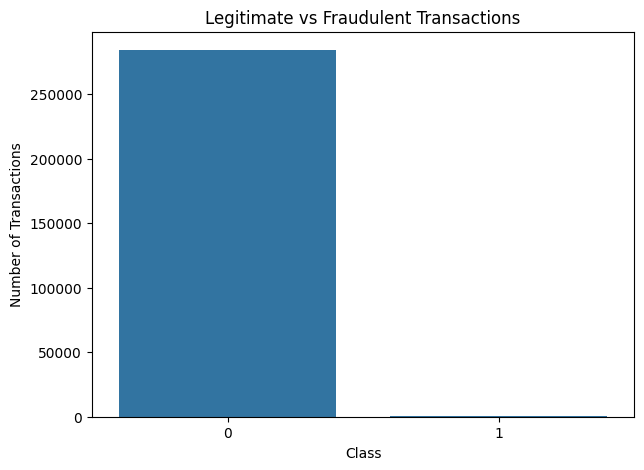

In [11]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.savefig("../images/1_class_distribution.png")
plt.show()

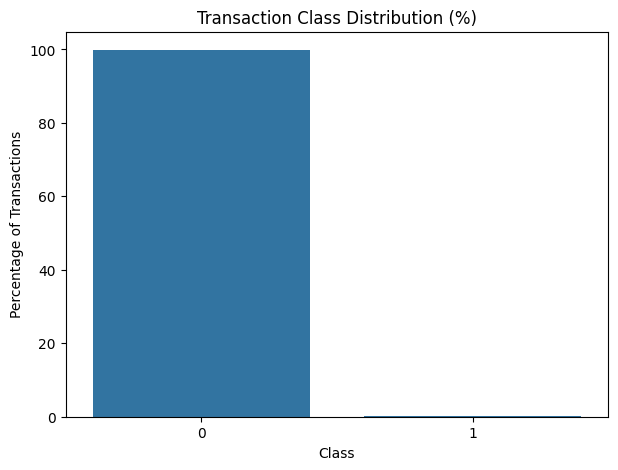

In [12]:
class_percentages = df["Class"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 5))
sns.barplot(x=class_percentages.index, y=class_percentages.values)

plt.title("Transaction Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage of Transactions")
plt.savefig("../images/2_class_distribution_percentage.png")
plt.show()

## Naive Baseline

Before building a machine learning model, it is useful to create a very simple baseline.

Because legitimate transactions make up almost the entire dataset, we can create a naive classifier that predicts every transaction as legitimate.

This baseline is intentionally simple. Its purpose is to show why accuracy can be misleading when the target classes are highly imbalanced.

In [13]:
baseline_predictions = np.zeros(len(df), dtype=int)
baseline_accuracy = (baseline_predictions == df["Class"]).mean()
baseline_accuracy

np.float64(0.9982725143693799)

In [14]:
baseline_accuracy * 100

np.float64(99.82725143693798)

### Baseline Fraud Metrics

In [15]:
baseline_precision = precision_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    df["Class"],
    baseline_predictions,
    zero_division=0
)

baseline_precision, baseline_recall, baseline_f1

(0.0, 0.0, 0.0)

The naive baseline has 0 precision, 0 recall and 0 F1-score for the fraud class because it does not predict any transactions as fraudulent.

This makes the limitation of accuracy even clearer. Although the baseline achieves approximately 99.83% accuracy, it completely fails to identify fraud.

### Why Accuracy Is Misleading

The naive baseline achieves approximately 99.83% accuracy by predicting every transaction as legitimate.

However, this model detects no fraudulent transactions at all.

This shows that accuracy is not enough for this problem. A fraud detection model must be evaluated based on how well it identifies the rare fraudulent transactions, not just how many predictions it gets correct overall.

## Evaluation Metrics

Because fraud is the positive class, the main metrics need to focus on how well the model identifies fraudulent transactions.

### Precision

Precision answers:

"Of the transactions predicted as fraud, how many were actually fraud?"

A high precision means the model does not generate too many false fraud alerts.

### Recall

Recall answers:

"Of all the actual fraudulent transactions, how many did the model find?"

A high recall means fewer fraudulent transactions are missed.

### F1-score

F1-score combines precision and recall into a single metric.

It is useful when both false positives and false negatives matter.

### ROC-AUC

ROC-AUC measures how well the model separates the two classes across different classification thresholds.

### PR-AUC

PR-AUC summarizes the relationship between precision and recall across different thresholds.

For this project, PR-AUC is especially useful because the fraud class is extremely rare.

## False Positives and False Negatives

In fraud detection, there are two important types of mistakes.

A false positive happens when a legitimate transaction is incorrectly flagged as fraud.

A false negative happens when a fraudulent transaction is incorrectly classified as legitimate.

Both matter, but they have different business consequences. Missing a fraudulent transaction can result in financial loss, while incorrectly blocking a legitimate transaction can create a poor customer experience.

The later stages of the project will use this trade-off when choosing the final classification threshold.

## Class Distribution Summary

In [16]:
class_summary = pd.DataFrame({
    "Transaction Type": ["Legitimate", "Fraud"],
    "Count": [
        (df["Class"] == 0).sum(),
        (df["Class"] == 1).sum()
    ],
    "Percentage": [
        (df["Class"] == 0).mean() * 100,
        (df["Class"] == 1).mean() * 100
    ]
})

class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.827251
1,Fraud,492,0.172749


In [17]:
class_summary["Percentage"] = class_summary["Percentage"].round(2)
class_summary

,Transaction Type,Count,Percentage
0,Legitimate,284315,99.83
1,Fraud,492,0.17


## Part 01 Findings

The dataset contains 284,807 transactions across 31 columns.

There are 284,315 legitimate transactions and 492 fraudulent transactions. Fraud represents only 0.17% of all transactions.

The class distribution is therefore highly imbalanced.

A naive model that predicts every transaction as legitimate achieves approximately 99.83% accuracy but detects zero fraudulent transactions. This confirms that accuracy alone would give a misleading view of model performance.

For the rest of the project, precision, recall, F1-score, ROC-AUC, and PR-AUC will provide a more useful way to evaluate fraud detection models.